In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:

iris = load_iris()

X = iris.data
y = iris.target


In [3]:
df = pd.DataFrame(X, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
pd.DataFrame(X_scaled).head()

,0,1,2,3
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


In [6]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [7]:
print("Original Shape :", X.shape)
print("Reduced Shape :", X_pca.shape)

Original Shape : (150, 4)
Reduced Shape : (150, 2)


In [8]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,-2.264703,0.480027
1,-2.080961,-0.674134
2,-2.364229,-0.341908
3,-2.299384,-0.597395
4,-2.389842,0.646835


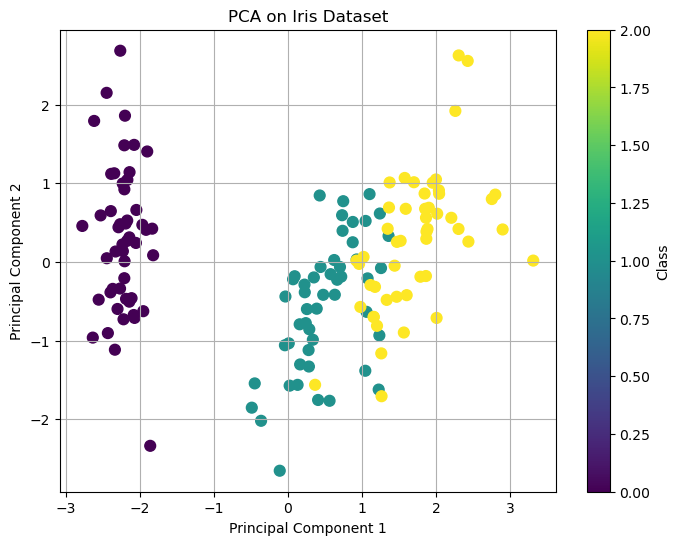

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='viridis',
    s=60
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA on Iris Dataset")

plt.colorbar(label="Class")

plt.grid(True)

plt.show()

In [11]:
print(pca.explained_variance_ratio_)

[0.72962445 0.22850762]


In [12]:
for i, variance in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {variance*100:.2f}%")

PC1: 72.96%
PC2: 22.85%


In [13]:
print("Total Variance Retained:",
      np.sum(pca.explained_variance_ratio_))

Total Variance Retained: 0.9581320720000164


In [14]:
loading = pd.DataFrame(
    pca.components_,
    columns=iris.feature_names,
    index=["PC1","PC2"]
)

print(loading)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
PC1           0.521066         -0.269347           0.580413          0.564857
PC2           0.377418          0.923296           0.024492          0.066942


# Output Summary
- Original Features	4
- Reduced Features	2
- Variance Retained	≈96%
- Algorithm	PCA
- Dataset	Iris

In [15]:
from sklearn.cluster import KMeans
# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_pca)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


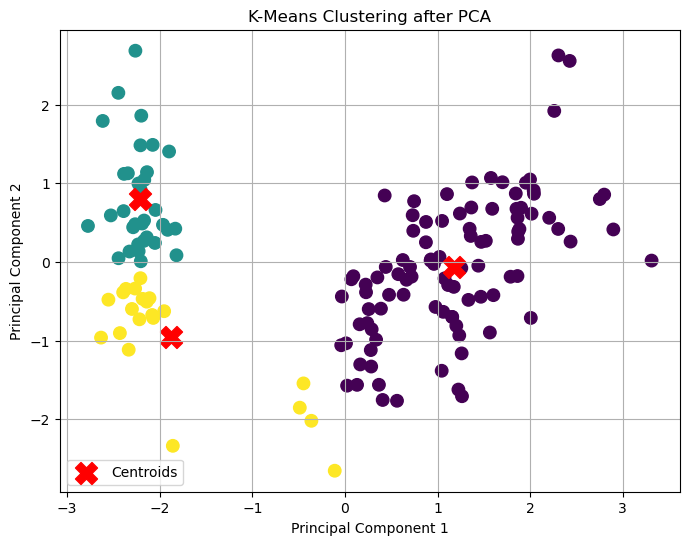

In [17]:
# Plot clusters
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels,
    cmap='viridis',
    s=80
)

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    c='red',
    marker='X',
    s=250,
    label='Centroids'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering after PCA")
plt.legend()
plt.grid(True)
plt.show()
